## Introduction

The goal of this project is to apply data visualisation and data analysis techniques to explore the Coursera Course Dataset. This dataset offers insights into the variety, popularity, and pricing of Coursera courses. As the final assignment for this Sprint, the objective is to leverage the tools and techniques learned throughout this course to analyze and extract meaningful information from the dataset.

Coursera is a leading online learning platform that provides a vast array of courses from institutions and companies worldwide. The platform offers both free and paid courses, targeting diverse audiences and subject areas. The dataset provides an opportunity to explore course details, ratings, enrollments, pricing structures, and more.

The notebook is structured as follows:

1. Data Loading: Downloading and loading the dataset.
2. Data Cleaning: Preparing the data for EDA. 
3. Exploratory Data Analysis (EDA): Delve into the dataset through impactful visualisations. 
4. Conclusions and suggestions for Improvements: Reflect on the results, recognise limitations and propose suggestions for future projects. 

## 1. Data Loading

In this section, we load the dataset and display the first few rows to ensure it's loaded correctly.


In [1]:
import pandas as pd

df = pd.read_csv('coursea_data.csv')

df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df['course_Certificate_type'] = df['course_Certificate_type'].replace('SPEFCIALIZATION', 'SPECIALIZATION')

print("Columns after removing unnamed columns:")
print(df.columns)

df.head(10)


Columns after removing unnamed columns:
Index(['course_title', 'course_organization', 'course_Certificate_type',
       'course_rating', 'course_difficulty', 'course_students_enrolled'],
      dtype='object')


,course_title,course_organization,course_Certificate_type,course_rating,course_difficulty,course_students_enrolled
0,(ISC)² Systems Security Certified Practitioner...,(ISC)²,SPECIALIZATION,4.7,Beginner,5.3k
1,A Crash Course in Causality: Inferring Causal...,University of Pennsylvania,COURSE,4.7,Intermediate,17k
2,A Crash Course in Data Science,Johns Hopkins University,COURSE,4.5,Mixed,130k
3,A Law Student's Toolkit,Yale University,COURSE,4.7,Mixed,91k
4,A Life of Happiness and Fulfillment,Indian School of Business,COURSE,4.8,Mixed,320k
5,ADHD: Everyday Strategies for Elementary Students,University at Buffalo,COURSE,4.7,Beginner,39k
6,AI For Everyone,deeplearning.ai,COURSE,4.8,Beginner,350k
7,AI For Medical Treatment,deeplearning.ai,COURSE,4.8,Intermediate,2.4k
8,AI Foundations for Everyone,IBM,SPECIALIZATION,4.7,Beginner,61k
9,AI for Medical Diagnosis,deeplearning.ai,COURSE,4.7,Intermediate,12k


## 2. Data Cleaning

In this section, we'll clean the dataset by removing unnecessary columns, handling missing values, and eliminating duplicates.

### Handling Missing Values

In this step, we check for missing values in the dataset and handle them by either removing rows with missing values or filling them with appropriate values.


In [2]:
missing_values = df.isnull().sum()
print("Missing values in the dataset:\n", missing_values)

df.dropna(inplace=True)

missing_values_after = df.isnull().sum()
print("Missing values after handling:\n", missing_values_after)

Missing values in the dataset:
 course_title                0
course_organization         0
course_Certificate_type     0
course_rating               0
course_difficulty           0
course_students_enrolled    0
dtype: int64
Missing values after handling:
 course_title                0
course_organization         0
course_Certificate_type     0
course_rating               0
course_difficulty           0
course_students_enrolled    0
dtype: int64


#### Results and Explanation

From the output, we see that there are **no missing values** in any of the columns. This means that the dataset is already clean with respect to missing data, and no further action was necessary for this step. 

Since we did not find any missing values, the second option (filling missing values) was not needed.

### Removing Duplicates

We now remove any duplicate rows and columns in the dataset. Duplicate features will be removed if found.


In [3]:

rows_before, cols_before = df.shape
print(f"Shape of the dataset before removing duplicates: {rows_before} rows, {cols_before} columns")

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

df.drop_duplicates(inplace=True)

rows_after, cols_after = df.shape
print(f"Shape of the dataset after removing duplicates: {rows_after} rows, {cols_after} columns")

Shape of the dataset before removing duplicates: 891 rows, 6 columns
Number of duplicate rows: 0
Shape of the dataset after removing duplicates: 891 rows, 6 columns


#### Results and Explanation
- Before checking for duplicates, the dataset had **891 rows and 6 columns**.
- After checking for duplicates, no duplicates were found, and the dataset still contains **891 rows and 6 columns**. This indicates that the dataset is clean with no duplicate entries.


### Cleaning 'course_students_enrolled'
The `course_students_enrolled` column contains enrollment numbers in a format such as `'5.3k'` (thousands). To enable numerical analysis, these values are converted to numeric format using a custom function:
- `'5.3k'` → `5300`
This ensures the column is ready for statistical analysis and visualization.

In [4]:
import numpy as np

def convert_enrollment(value):
    if isinstance(value, str) and 'k' in value:
        return float(value.replace('k', '')) * 1000
    elif isinstance(value, str) and 'm' in value:
        return float(value.replace('m', '')) * 1000000
    else:
        return float(value)

df['course_students_enrolled'] = df['course_students_enrolled'].apply(convert_enrollment)

print(df['course_students_enrolled'].head())



0      5300.0
1     17000.0
2    130000.0
3     91000.0
4    320000.0
Name: course_students_enrolled, dtype: float64


### Identifying the outliers
In this step, we analyse the distribution of numerical features to identify potential outliers. We use boxplots and descriptive statistics to assess whether outliers exist and if they impact our analysis.

Numerical columns identified for analysis: Index(['course_rating', 'course_students_enrolled'], dtype='object')


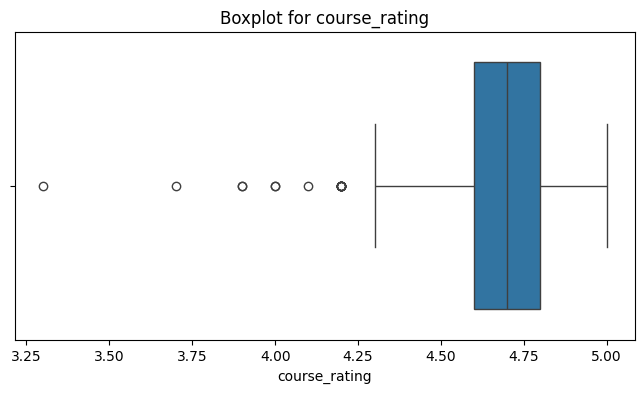

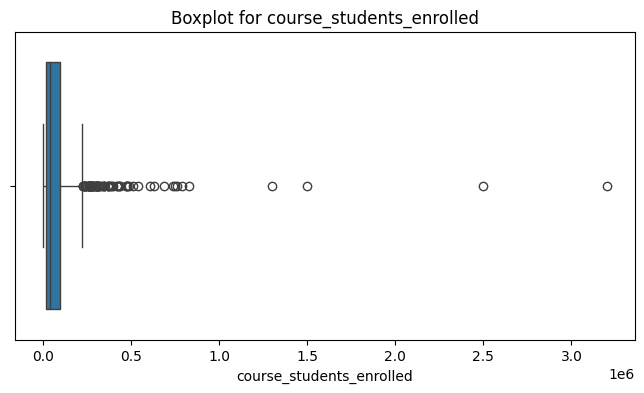

Summary statistics for numerical columns:
       course_rating  course_students_enrolled
count     891.000000              8.910000e+02
mean        4.677329              9.055208e+04
std         0.162225              1.819365e+05
min         3.300000              1.500000e+03
25%         4.600000              1.750000e+04
50%         4.700000              4.200000e+04
75%         4.800000              9.950000e+04
max         5.000000              3.200000e+06


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = df.select_dtypes(include=[float, int]).columns
print(f"Numerical columns identified for analysis: {numerical_columns}")

for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot for {col}")
    plt.xlabel(col)
    plt.show()

print("Summary statistics for numerical columns:")
print(df[numerical_columns].describe())

def identify_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"\n{column} Outlier Analysis:")
    print(f"Q1 = {Q1}, Q3 = {Q3}, IQR = {IQR}")
    print(f"Lower Bound = {lower_bound}, Upper Bound = {upper_bound}")
    # Filter rows with outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers


#### Explanation

The summary statistics above provide insights into the numerical columns of the dataset: `course_rating` and `course_students_enrolled`. Here's what the key statistics reveal:

1. Count:
   - Both columns have 891 non-null values, indicating there are no missing values in these fields.

2. Mean:
   - The average course rating is 4.68, which shows that most courses are highly rated.
   - The average number of students enrolled is 90,552, indicating that courses on Coursera attract a significant number of learners.

3. Standard Deviation (std):
   - The course ratings have a small standard deviation (0.16), meaning most ratings are clustered around the average.
   - The enrollments, however, have a large standard deviation (181,936), showing a wide range of student numbers across courses.

4. Minimum and Maximum:
   - The lowest course rating is 3.3, while the highest is 5.0, confirming that Coursera courses are generally well-rated.
   - The smallest enrollment is 1,500 students, and the highest is 3,200,000 students, indicating the presence of extremely popular courses.

5. Quartiles (25%, 50%, 75%):
   - Course Rating:
     - 25% of the courses have a rating below 4.6, and 75% are below 4.8, reflecting a skew towards high ratings.
   - Course Enrollment:
     - 25% of the courses have fewer than 17,500 students, and 75% have fewer than 99,500 students, meaning most courses have moderate enrollments, with a few exceptions.

Key Takeaways:
- Course Ratings: Most courses have high ratings (4.6 to 5.0), indicating learner satisfaction.
- Enrollments: There is a significant variation in enrollments, with a few outliers having extremely high numbers (e.g., 3.2M). These outliers contribute to the high standard deviation in enrollments.

This information helps us understand the data distribution and guides further analysis, especially identifying outliers in the dataset.


## Treating Outliers

Building on the analysis above, we will now selectively remove specific outliers to refine the dataset. This step ensures that extreme values do not skew the results while preserving the representativeness of the data for meaningful analysis.

In [6]:

enrollment_upper_threshold = 1_000_000  
rating_lower_threshold = 4.0          

df_cleaned = df[
    (df['course_students_enrolled'] <= enrollment_upper_threshold) &
    (df['course_rating'] >= rating_lower_threshold)
]

print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")

removed_enrollments = df[df['course_students_enrolled'] > enrollment_upper_threshold]
removed_ratings = df[df['course_rating'] < rating_lower_threshold]

print("\nCourses removed due to high enrollments:")
print(removed_enrollments[['course_title', 'course_students_enrolled']])

print("\nCourses removed due to low ratings:")
print(removed_ratings[['course_title', 'course_rating']])


Original dataset shape: (891, 6)
Cleaned dataset shape: (883, 6)

Courses removed due to high enrollments:
                                          course_title  \
564                                   Machine Learning   
674  Programming for Everybody (Getting Started wit...   
688                               Python for Everybody   
815                          The Science of Well-Being   

     course_students_enrolled  
564                 3200000.0  
674                 1300000.0  
688                 1500000.0  
815                 2500000.0  

Courses removed due to low ratings:
                                          course_title  course_rating
413  How To Create a Website in a Weekend! (Project...            3.3
566  Machine Learning and Reinforcement Learning in...            3.7
569                       Machine Learning for Trading            3.9
873                     iOS App Development with Swift            3.9


#### Explanation
1. Shape of the Dataset:
    - The original dataset shape reflects the total number of courses before any outlier treatment.
    - The cleaned dataset shape shows the reduced number of courses after removing outliers.

2. Courses Removed:
    - Courses with enrollments exceeding 1,000,000 (outliers) were removed. These values represent an extreme minority and can skew enrollment-based analyses.
    - Courses with ratings below 4.0 were removed, as they represent exceptionally low-rated courses and can distort overall insights into course quality.

The filtered dataset is now better suited for analysis, as it excludes extreme outliers while retaining valuable trends and insights from the majority of courses.

### Final Cleaned Dataset Information

After handling missing values, removing duplicates, and treating outliers. Below, we compare the number of entries in the original and cleaned datasets to illustrate the impact of the cleaning process. This cleaned dataset will serve as the foundation for the exploratory data analysis (EDA) phase, ensuring meaningful insights.


In [7]:
print(f"Number of entries in the original dataset: {len(df)}")
print(f"Number of entries in the cleaned dataset: {len(df_cleaned)}")

Number of entries in the original dataset: 891
Number of entries in the cleaned dataset: 883


# 3. Exploratory Data Analysis (EDA)

### How many observations (rows) and features (columns) are there in the dataset?

In [8]:
num_rows = df_cleaned.shape[0]
print(f"Number of observations (rows): {num_rows}")

num_columns = df_cleaned.shape[1]
print(f"Number of features (columns): {num_columns}")

Number of observations (rows): 883
Number of features (columns): 6


### Which of the features are categorical and numeric? 

In [9]:
categorical_features = df_cleaned.select_dtypes(include=['object']).columns.tolist()
numerical_features = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")

Categorical features: ['course_title', 'course_organization', 'course_Certificate_type', 'course_difficulty']
Numerical features: ['course_rating', 'course_students_enrolled']


**What This Means**:
- Categorical features represent non-numeric, textual, descriptive or categorical data such as course title, organisation, type and difficulty.
- Numeric features contain quantitive values including course rating and number of students enrolled. This will be helpful for analysis and visualisation.

### What is the distribution of course ratings across all courses?

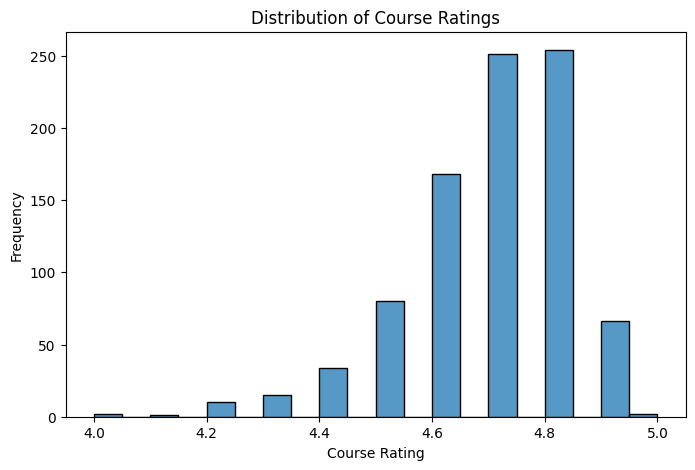

Course Rating Distribution:
Rating 4.0: 2 courses
Rating 4.1: 1 courses
Rating 4.2: 10 courses
Rating 4.3: 15 courses
Rating 4.4: 34 courses
Rating 4.5: 80 courses
Rating 4.6: 168 courses
Rating 4.7: 251 courses
Rating 4.8: 254 courses
Rating 4.9: 66 courses
Rating 5.0: 2 courses


In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df_cleaned['course_rating'], bins=20)
plt.title("Distribution of Course Ratings")
plt.xlabel("Course Rating")
plt.ylabel("Frequency")
plt.show()

rating_counts = df_cleaned['course_rating'].value_counts().sort_index()

print("Course Rating Distribution:")
for rating, count in rating_counts.items():
    print(f"Rating {rating}: {count} courses")

**What This Means**:
- The histogram shows how course ratings are distributed. 
- As most ratings are above 4.0, it suggests that Coursera courses generally receive positive feedback from learners.
- 505 courses (more than half) fall between 4.7 and 4.8**, reinforcing that top-rated courses dominate the platform.


### Which courses have the highest ratings?

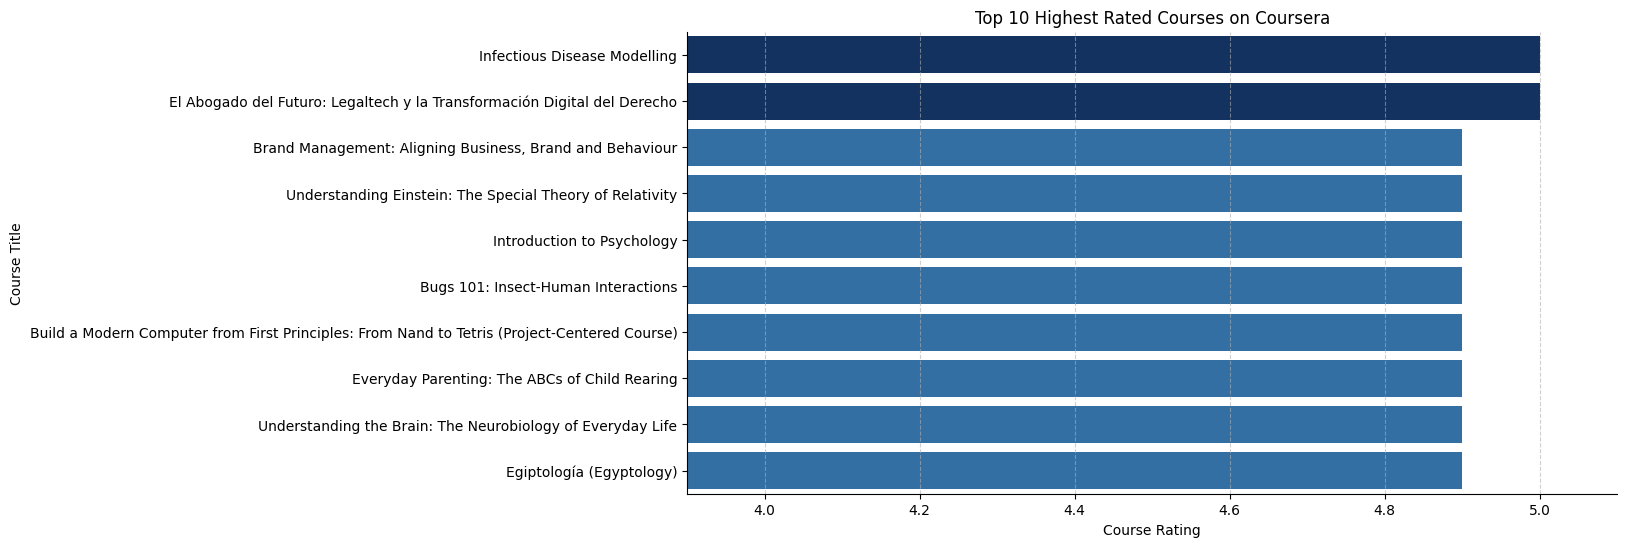

Highest Rated Courses:

                                                                                course_title  course_rating
                                                                Infectious Disease Modelling            5.0
                    El Abogado del Futuro: Legaltech y la Transformación Digital del Derecho            5.0
                                    Brand Management: Aligning Business, Brand and Behaviour            4.9
                                    Understanding Einstein: The Special Theory of Relativity            4.9
                                                                  Introduction to Psychology            4.9
                                                         Bugs 101: Insect-Human Interactions            4.9
Build a Modern Computer from First Principles: From Nand to Tetris (Project-Centered Course)            4.9
                                               Everyday Parenting: The ABCs of Child Rearing            4.9
    

In [11]:

highest_rated_courses = df_cleaned[['course_title', 'course_rating']].sort_values(
    by='course_rating', ascending=False).head(10)

plt.figure(figsize=(12, 6))

colors = ['#08306b' if rating == 5.0 else '#2171b5' for rating in highest_rated_courses['course_rating']]

sns.barplot(data=highest_rated_courses, 
            y='course_title', 
            x='course_rating', 
            hue=highest_rated_courses['course_title'],  
            dodge=False,         
            legend=False,        
            palette=colors)       

plt.xlabel("Course Rating")
plt.ylabel("Course Title")
plt.title("Top 10 Highest Rated Courses on Coursera")
plt.xlim(3.9, 5.1)  
plt.grid(axis='x', linestyle="--", alpha=0.6)

sns.despine()
plt.show()

print("Highest Rated Courses:\n")
print(highest_rated_courses.to_string(index=False, header=True))

**What it means:**
- The 5.0-rated courses ("Infectious Disease Modelling" and "El Abogado del Futuro") stand out as exceptional, likely due to their quality, depth, and relevance.
- The 4.9-rated courses cover a diverse range of subjects, including business, psychology, computer science, and science-based topics.
- Courses related to psychology appear frequently, suggesting high learner interest in this areas.

### Which courses have the lowest ratings?

Lowest Rated Courses:
                                   course_title  course_rating
Introduction to Trading, Machine Learning & GCP            4.0
          Mathematics for Machine Learning: PCA            4.0
                 How to Start Your Own Business            4.1
          Unity XR: How to Build AR and VR Apps            4.2
 Hardware Description Languages for FPGA Design            4.2
              Cybersecurity and Its Ten Domains            4.2
                            Optical Engineering            4.2
                 Aprende a programar con Python            4.2
                              Project Execution            4.2
               Mastering Data Analysis in Excel            4.2


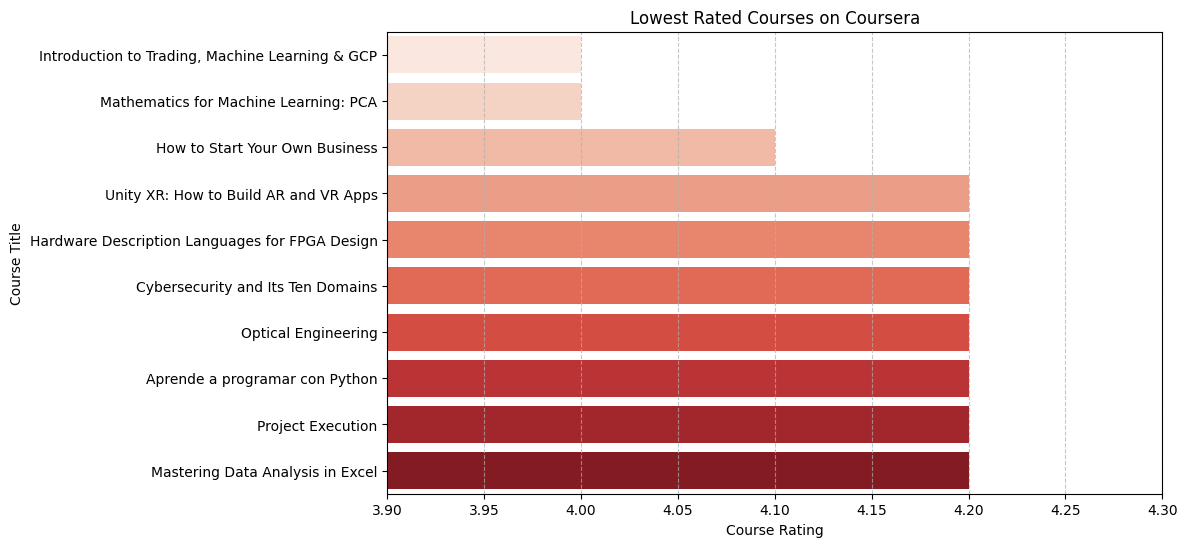

In [12]:
lowest_rated_courses = df_cleaned[['course_title', 'course_rating']].sort_values(by='course_rating', ascending=True).head(10)

print("Lowest Rated Courses:")
print(lowest_rated_courses.to_string(index=False, header=True))

plt.figure(figsize=(10, 6))
sns.barplot(data=lowest_rated_courses, 
            x='course_rating', 
            y='course_title', 
            hue='course_title',  
            dodge=False,          
            legend=False,         
            palette="Reds")

plt.title("Lowest Rated Courses on Coursera")
plt.xlabel("Course Rating")
plt.ylabel("Course Title")
plt.xlim(3.9, 4.3)  
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**What This Means**:
- The table shows the 10 lowest-rated courses on Coursera, with ratings between 4.0 and 4.2. While these are not extremely low, they are below the platform's typical high ratings.
- The courses cover various topics, including trading, machine learning, cybersecurity, business, and programming.
- Many of these are technical subjects, such as FPGA design, XR development, and data analysis.
- Some courses may be more challenging or outdated, leading to lower student satisfaction.

### Do low rated courses below 4.5 have a lower student enrollment? 

Student Enrollment by Course Rating Category:
Total enrollment for courses rated below 4.5: 4,123,800.0 students
Total enrollment for courses rated 4.5 and above: 67,798,100.0 students
Average enrollment for courses rated below 4.5: 66,513 students
Average enrollment for courses rated 4.5 and above: 82,580 students


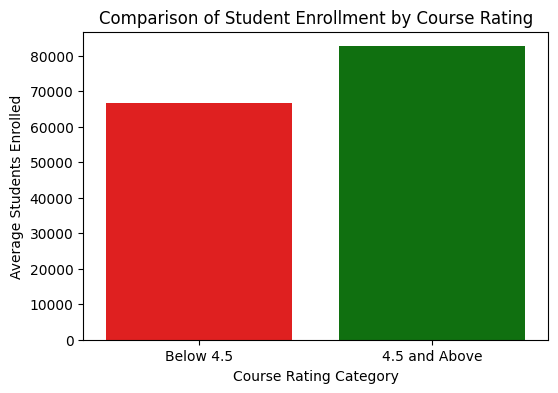

In [13]:
low_rated_courses = df_cleaned[df_cleaned['course_rating'] < 4.5]
high_rated_courses = df_cleaned[df_cleaned['course_rating'] >= 4.5]

total_enrollment_low = low_rated_courses['course_students_enrolled'].sum()
total_enrollment_high = high_rated_courses['course_students_enrolled'].sum()

avg_enrollment_low = round(low_rated_courses['course_students_enrolled'].mean())
avg_enrollment_high = round(high_rated_courses['course_students_enrolled'].mean())

print("Student Enrollment by Course Rating Category:")
print(f"Total enrollment for courses rated below 4.5: {total_enrollment_low:,} students")
print(f"Total enrollment for courses rated 4.5 and above: {total_enrollment_high:,} students")
print(f"Average enrollment for courses rated below 4.5: {avg_enrollment_low:,} students")
print(f"Average enrollment for courses rated 4.5 and above: {avg_enrollment_high:,} students")

plt.figure(figsize=(6,4))
sns.barplot(x=['Below 4.5', '4.5 and Above'], 
            y=[avg_enrollment_low, avg_enrollment_high], 
            hue=['Below 4.5', '4.5 and Above'],
            palette=["red", "green"], 
            legend=False)  

plt.title("Comparison of Student Enrollment by Course Rating")
plt.ylabel("Average Students Enrolled")
plt.xlabel("Course Rating Category")
plt.show()

**What This Means**:
- Higher-rated courses (≥ 4.5) attract significantly more students both in total and on average per course.
- Courses rated below 4.5 have lower enrollments, with an average of 66,513 students compared to 82,580 students for higher-rated courses.
- The total enrollment gap is substantial—highly-rated courses have over 16 times more students than lower-rated courses.

### What is the distribution of the number of students enrolled across all courses?


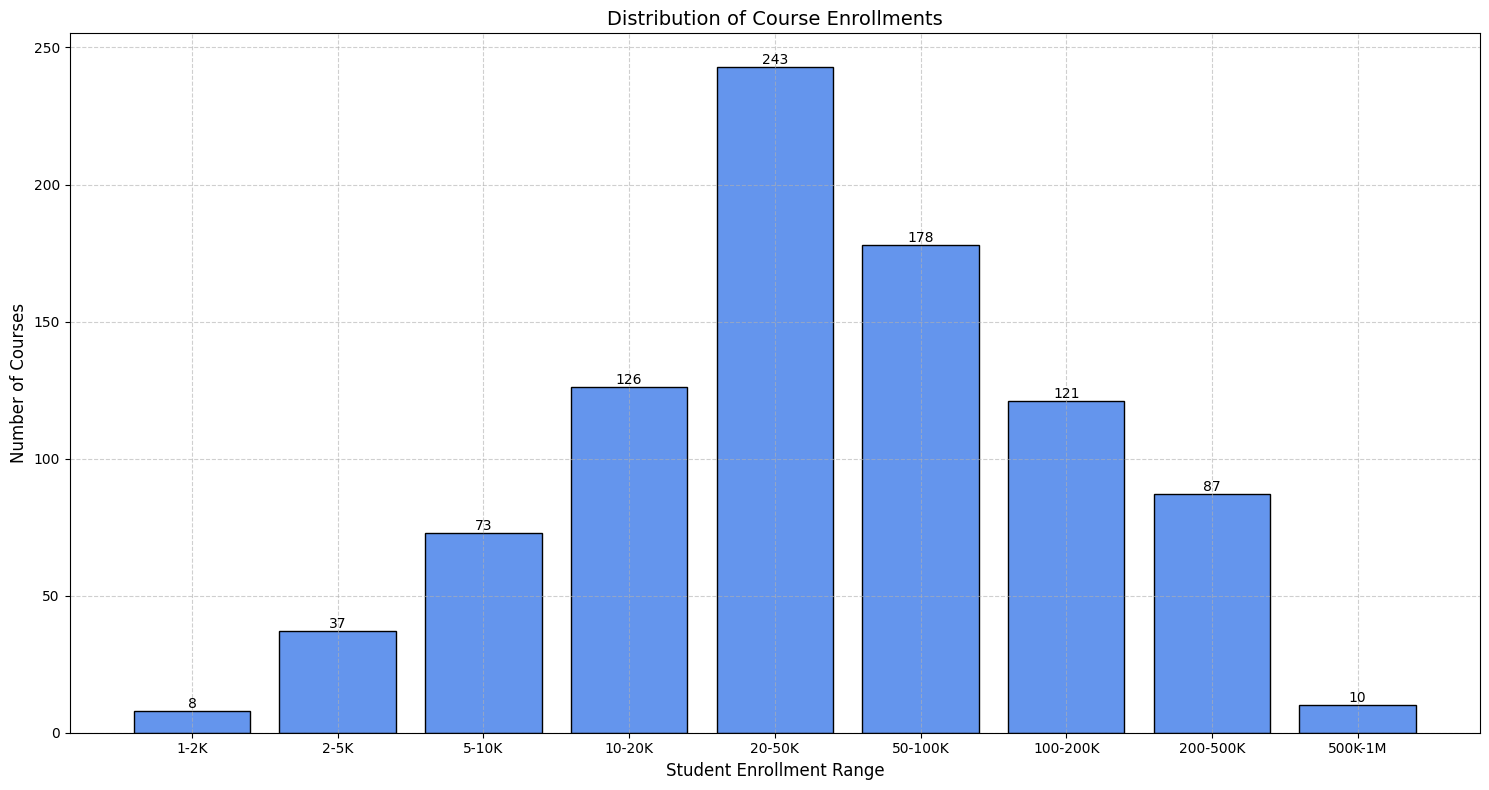


Summary Statistics:
Low Enrollment (<1,000 students): 0 courses
Medium Enrollment (1,000-50,000 students): 487 courses
High Enrollment (≥50,000 students): 396 courses


In [14]:
plt.figure(figsize=(15, 8), facecolor='white')

bins = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000]
labels = ['1-2K', '2-5K', '5-10K', '10-20K', '20-50K', '50-100K', '100-200K', '200-500K', '500K-1M']

df_analysis = df_cleaned.copy()
df_analysis.loc[:, 'enrollment_range'] = pd.cut(df_analysis['course_students_enrolled'],bins=bins,labels=labels,right=False)

counts = df_analysis['enrollment_range'].value_counts().sort_index()

bars = plt.bar(labels, counts, color='cornflowerblue', edgecolor='black')

plt.grid(True, linestyle='--', alpha=0.6, zorder=0)
plt.xlabel('Student Enrollment Range', fontsize=12)
plt.ylabel('Number of Courses', fontsize=12)
plt.title('Distribution of Course Enrollments', fontsize=14)

plt.xticks(rotation=0)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.grid(True, axis='y', linestyle='--', alpha=0.6, zorder=0)

low_enrollment_count = df_cleaned.loc[df_cleaned['course_students_enrolled'] < 1000].shape[0]
medium_enrollment_count = df_cleaned.loc[(df_cleaned['course_students_enrolled'] >= 1000) & 
                                       (df_cleaned['course_students_enrolled'] < 50000)].shape[0]
high_enrollment_count = df_cleaned.loc[df_cleaned['course_students_enrolled'] >= 50000].shape[0]

plt.tight_layout()
plt.show()

print("\nSummary Statistics:")
print(f"Low Enrollment (<1,000 students): {low_enrollment_count} courses")
print(f"Medium Enrollment (1,000-50,000 students): {medium_enrollment_count} courses")
print(f"High Enrollment (≥50,000 students): {high_enrollment_count} courses")

**What this means:**
- Most courses (487) fall within 1K-50K enrollments, with the 20K-50K range being the most common (243 courses).  
- Highly popular courses (≥50K students) make up a significant portion (396 courses), with peaks in the 50K-100K and 100K-200K ranges.  
- No courses have fewer than 1,000 students, indicating a baseline demand.  

### What are the courses with the highest enrollments?

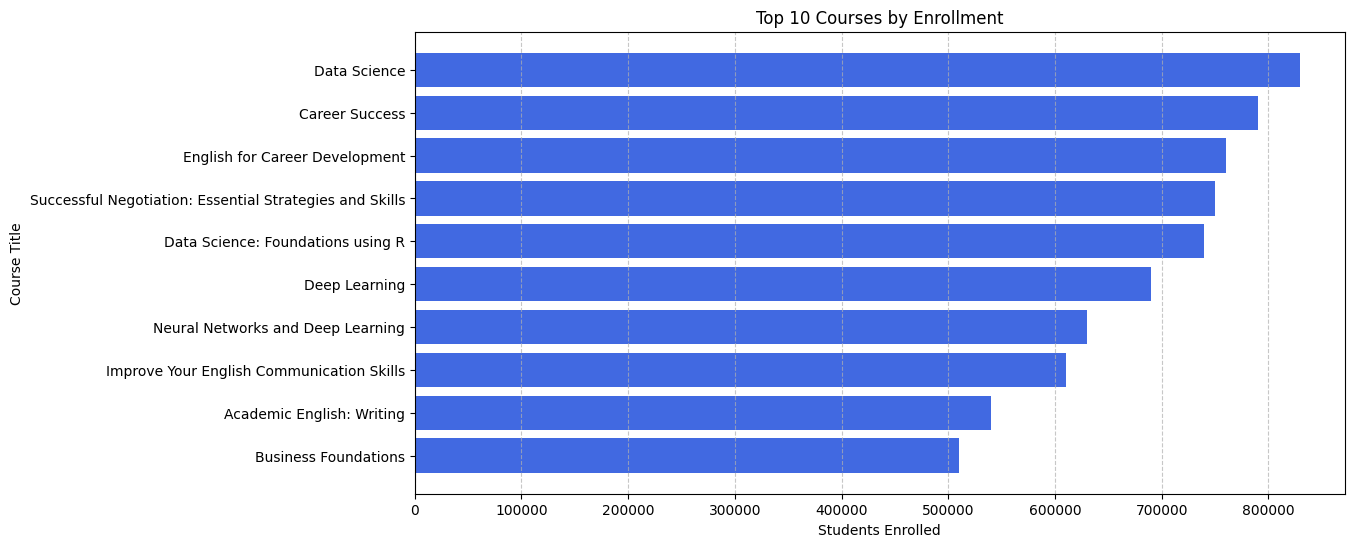

                                           course_title  course_students_enrolled
                                           Data Science                  830000.0
                                         Career Success                  790000.0
                         English for Career Development                  760000.0
Successful Negotiation: Essential Strategies and Skills                  750000.0
                      Data Science: Foundations using R                  740000.0
                                          Deep Learning                  690000.0
                      Neural Networks and Deep Learning                  630000.0
              Improve Your English Communication Skills                  610000.0
                              Academic English: Writing                  540000.0
                                   Business Foundations                  510000.0


In [15]:

highest_enrollment_courses = df_cleaned[['course_title', 'course_students_enrolled']].sort_values(
    by='course_students_enrolled', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(highest_enrollment_courses["course_title"], highest_enrollment_courses["course_students_enrolled"], color='royalblue')
plt.xlabel("Students Enrolled")
plt.ylabel("Course Title")
plt.title("Top 10 Courses by Enrollment")
plt.gca().invert_yaxis()  
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

print(highest_enrollment_courses.to_string(index=False, header=True))


**What it means:**
- Most Popular: "Data Science" (830K students).
- High Demand Areas: Data Science, AI, Business, and Communication.
- Career-Focused: Courses on negotiation, English, and success skills attract large enrollments.
- Takeaway: Tech and professional development courses dominate enrollment trends.

### What are the courses with the lowest enrollments?

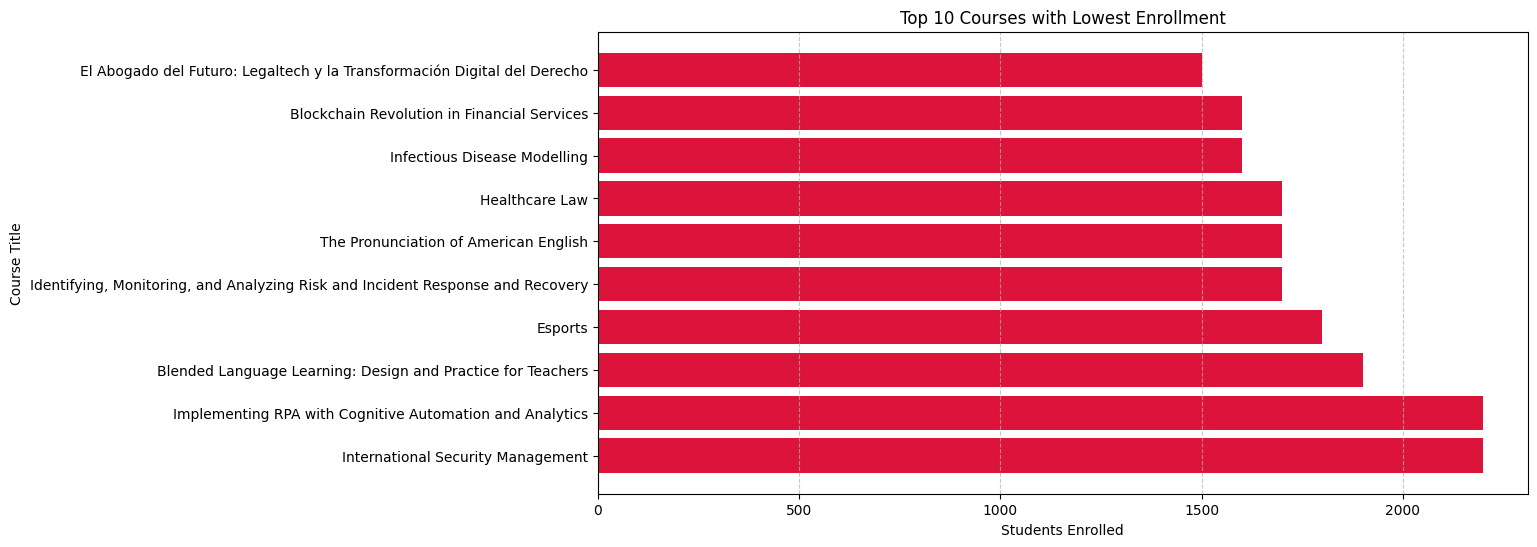

                                                                  course_title  course_students_enrolled
      El Abogado del Futuro: Legaltech y la Transformación Digital del Derecho                    1500.0
                                   Blockchain Revolution in Financial Services                    1600.0
                                                  Infectious Disease Modelling                    1600.0
                                                                Healthcare Law                    1700.0
                                         The Pronunciation of American English                    1700.0
Identifying, Monitoring, and Analyzing Risk and Incident Response and Recovery                    1700.0
                                                                       Esports                    1800.0
                   Blended Language Learning: Design and Practice for Teachers                    1900.0
                      Implementing RPA with Cognitive A

In [16]:

lowest_enrollment_courses = df_cleaned[['course_title', 'course_students_enrolled']].sort_values(
    by='course_students_enrolled', ascending=True).head(10)

plt.figure(figsize=(12, 6))
plt.barh(lowest_enrollment_courses["course_title"], lowest_enrollment_courses["course_students_enrolled"], color='crimson')
plt.xlabel("Students Enrolled")
plt.ylabel("Course Title")
plt.title("Top 10 Courses with Lowest Enrollment")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

print(lowest_enrollment_courses.to_string(index=False, header=True))

### How many courses are categorised as Beginner, Intermediate, Mixed and Advanced?

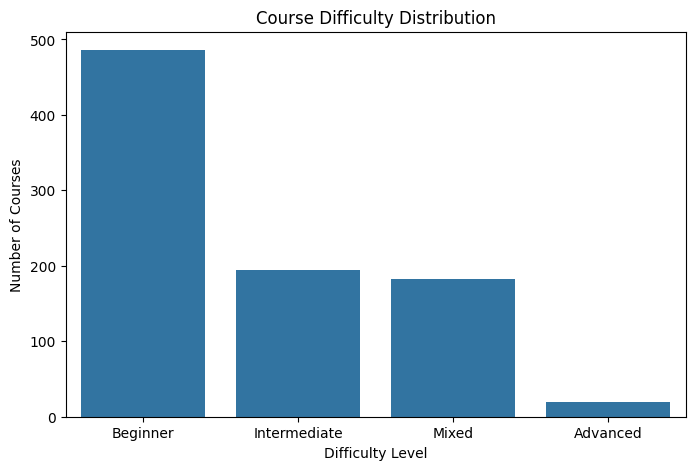

Course Difficulty Distribution:

course_difficulty
Beginner        486
Intermediate    195
Mixed           183
Advanced         19


In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_cleaned, x='course_difficulty')
plt.title("Course Difficulty Distribution")
plt.xlabel("Difficulty Level")
plt.ylabel("Number of Courses")
plt.show()

difficulty_counts = df_cleaned['course_difficulty'].value_counts()

print("Course Difficulty Distribution:\n")
print(difficulty_counts.to_string())

**What This Means**:
- Beginner courses dominate (486 courses), making up the majority.
- Intermediate (195) and Mixed (183) courses** are fairly balanced.
- Advanced courses (19) are rare, indicating fewer high-level offerings.
- The visualisation reinforces that most courses cater to beginners, with fewer progressing to advanced difficulty.

### What is the average enrollment for each difficulty level?

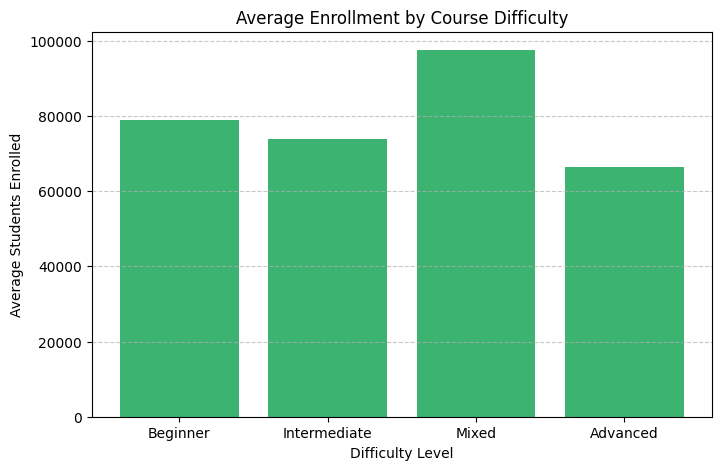

Average Enrollment by Course Difficulty:

course_difficulty  average_enrollment
         Beginner             79057.0
     Intermediate             73776.0
            Mixed             97538.0
         Advanced             66547.0


In [18]:

average_enrollment_by_difficulty = df_cleaned.groupby('course_difficulty')['course_students_enrolled'].mean().round()

df_avg_enrollment = pd.DataFrame(list(average_enrollment_by_difficulty.items()), columns=["course_difficulty", "average_enrollment"])

difficulty_order = ["Beginner", "Intermediate", "Mixed", "Advanced"]

df_avg_enrollment["course_difficulty"] = pd.Categorical(df_avg_enrollment["course_difficulty"], categories=difficulty_order, ordered=True)
df_avg_enrollment = df_avg_enrollment.sort_values("course_difficulty")

plt.figure(figsize=(8, 5))
plt.bar(df_avg_enrollment["course_difficulty"], df_avg_enrollment["average_enrollment"], color='mediumseagreen')
plt.title("Average Enrollment by Course Difficulty")
plt.xlabel("Difficulty Level")
plt.ylabel("Average Students Enrolled")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print("Average Enrollment by Course Difficulty:\n")
print(df_avg_enrollment.to_string(index=False))



**What This Means:** 
- Mixed-difficulty courses have the highest average enrollment (97,538 students), suggesting broad appeal across different skill levels.
- Beginner courses attract a significant number of students (79,057), likely due to accessibility and a larger audience.
- Intermediate courses have slightly lower average enrollments (73,776), possibly because they require prior knowledge.
- Advanced courses have the lowest average enrollment (66,547), indicating a smaller but more specialised audience.

### What is the average course rating for each difficulty level?

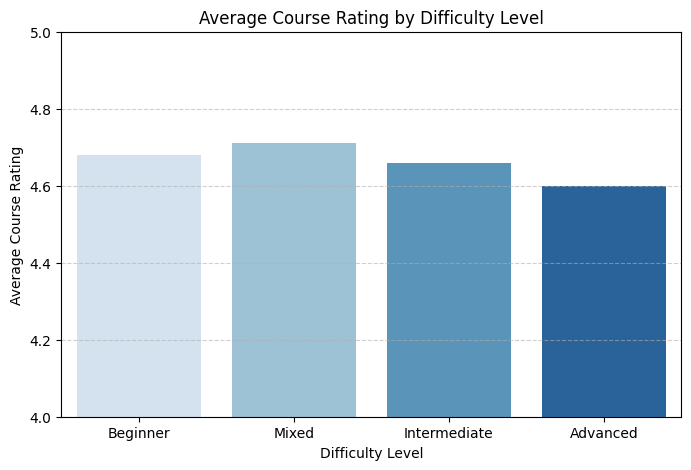

Average Course Rating by Difficulty Level:

course_difficulty
Beginner        4.68
Mixed           4.71
Intermediate    4.66
Advanced        4.60


In [19]:
difficulty_order = ["Beginner", "Mixed", "Intermediate", "Advanced"]

avg_rating_per_difficulty = df_cleaned.groupby('course_difficulty')['course_rating'].mean().round(2)

avg_rating_per_difficulty = avg_rating_per_difficulty.reindex(difficulty_order)

plt.figure(figsize=(8,5))

sns.barplot(data=avg_rating_per_difficulty.reset_index(), 
x='course_difficulty', 
y='course_rating', 
hue='course_difficulty', 
dodge=False, legend=False, palette="Blues")

plt.title("Average Course Rating by Difficulty Level")
plt.xlabel("Difficulty Level")
plt.ylabel("Average Course Rating")
plt.ylim(4, 5)  # Adjust y-axis for better visualization
plt.grid(axis='y', linestyle="--", alpha=0.6)

plt.show()

print("Average Course Rating by Difficulty Level:\n")
print(avg_rating_per_difficulty.to_string())

**What This Means:** 
- Mixed-difficulty courses have the highest average rating at 4.71, suggesting that courses catering to multiple skill levels may be well-received.
- Beginner courses also have a relatively high average rating of 4.68, indicating that entry-level courses tend to be rated positively.
- Intermediate courses have an average rating of 4.66, slightly lower than beginner and mixed courses.
- Advanced courses have the lowest average rating at 4.60, which might suggest that learners find them more challenging or have higher expectations for advanced content.
- Overall, while the differences are not drastic, the trend suggests that courses designed for broader or less experienced audiences tend to receive slightly higher ratings compared to advanced courses.

### Is there a correlation between course rating and enrollment?

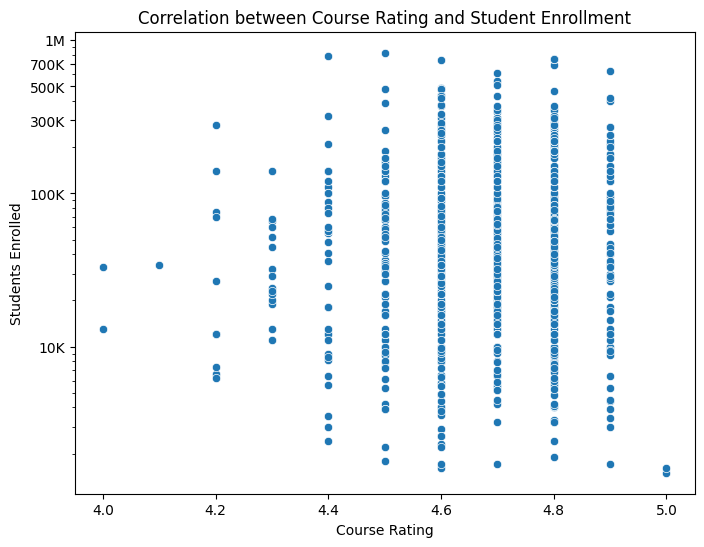

In [20]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df_cleaned['course_rating'], y=df_cleaned['course_students_enrolled'])

plt.title("Correlation between Course Rating and Student Enrollment")
plt.xlabel("Course Rating")
plt.ylabel("Students Enrolled")
plt.yscale("log")  # Log scale to handle skewed data

# Set y-axis ticks to increase in increments of 200,000
plt.yticks([1e4, 1e5, 3e5, 5e5, 7e5, 1e6], 
           ['10K', '100K', '300K', '500K', '700K', '1M'])

plt.show()



**What This Means:**
- Higher-rated courses (4.5 - 5.0) generally attract more students. 
- Lower-rated courses (4.0 - 4.3) tend to have fewer enrollments, but exceptions exist.
- The relationship is positive but not absolute, meaning factors beyond ratings influence student interest. 
- While higher ratings often correlate with higher enrollments, rating alone does not fully determine a course’s popularity as there are low enrollments for 5.0 rating. 

While higher-rated courses tend to attract more students, it’s not a strict rule, as seen by highly-rated courses with low enrollments.

### How many course providers are there in the dataset?

In [21]:
num_providers = df_cleaned['course_organization'].nunique()
print(f"Number of unique course providers: {num_providers}")

Number of unique course providers: 154


**What This Means:**
- The dataset contains 154 unique course providers, meaning that courses are offered by 154 different organisations. This diversity suggests a broad range of educational sources. 

### What is the distribution of courses among the course providers?


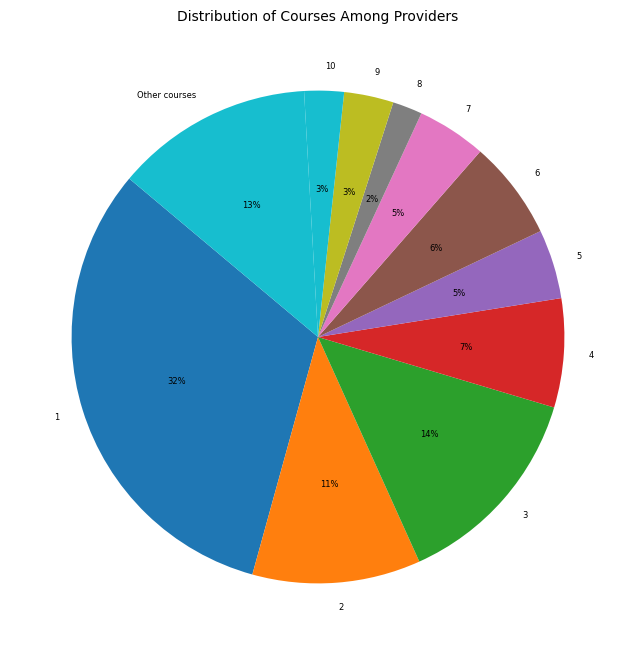

Number of providers offering the same number of courses:

49 providers offer 1 courses
17 providers offer 2 courses
21 providers offer 3 courses
11 providers offer 4 courses
7 providers offer 5 courses
10 providers offer 6 courses
7 providers offer 7 courses
3 providers offer 8 courses
5 providers offer 9 courses
4 providers offer 10 courses
2 providers offer 11 courses
2 providers offer 13 courses
2 providers offer 14 courses
1 providers offer 15 courses
2 providers offer 16 courses
2 providers offer 19 courses
1 providers offer 21 courses
2 providers offer 22 courses
1 providers offer 27 courses
2 providers offer 28 courses
1 providers offer 33 courses
1 providers offer 39 courses
1 providers offer 59 courses


In [22]:

provider_counts = df_cleaned['course_organization'].value_counts()

grouped_providers = provider_counts.value_counts().sort_index()

provider_counts = df_cleaned['course_organization'].value_counts()

grouped_providers = provider_counts.value_counts().sort_index()

top_n = 10 
top_providers = grouped_providers[:top_n]
other_providers = grouped_providers[top_n:].sum()
plot_data = pd.concat([top_providers, pd.Series({'Other courses': other_providers})])

colors = plt.colormaps.get_cmap("tab10")(range(len(plot_data)))

plt.figure(figsize=(8, 8))

plot_data.plot(kind='pie', 
               autopct='%1.0f%%', 
               startangle=140, 
               colors=colors, 
               textprops={'fontsize': 6})  

plt.title("Distribution of Courses Among Providers", fontsize=10)  
plt.ylabel('') 
plt.show()

print("Number of providers offering the same number of courses:\n")
for num_courses, num_providers in grouped_providers.items():
    print(f"{num_providers} providers offer {num_courses} courses")


**What This Means:**
- Most course providers offer several courses, with 32% providing just 1 course.  
- The number of providers decreases as course offerings increase.  
- A few providers dominate, with one offering 59 courses.  
- The pie chart visualises this distribution, grouping similar providers while reducing clutter.   

### Which 10 course providers have the average highest course ratings?

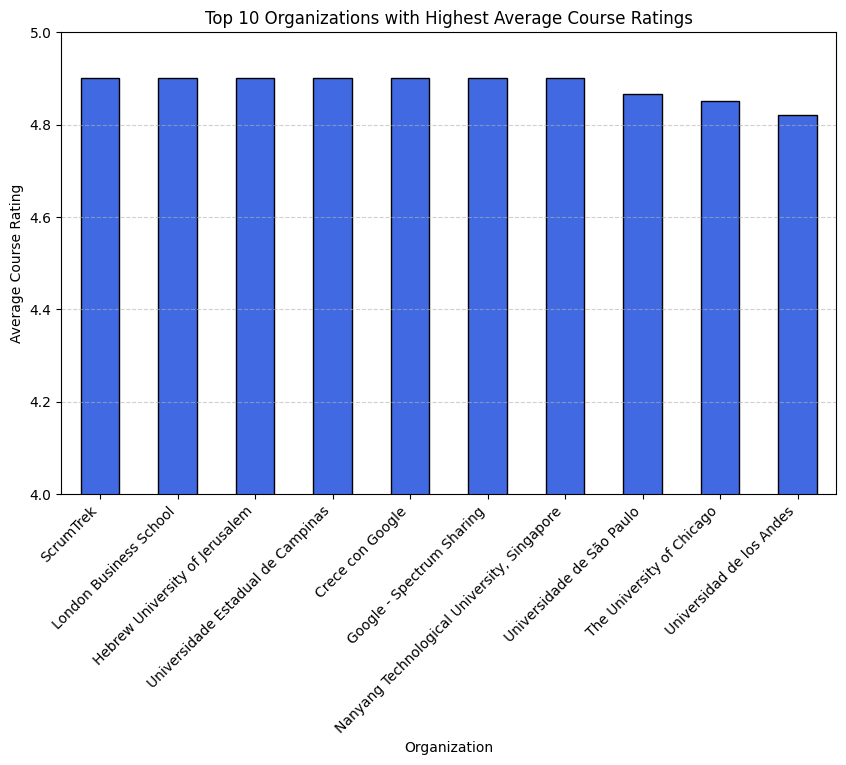

Top 10 Organizations with Highest Average Course Ratings:

course_organization
ScrumTrek                                      4.900000
London Business School                         4.900000
Hebrew University of Jerusalem                 4.900000
Universidade Estadual de Campinas              4.900000
Crece con Google                               4.900000
Google - Spectrum Sharing                      4.900000
Nanyang Technological University, Singapore    4.900000
Universidade de São Paulo                      4.866667
The University of Chicago                      4.850000
Universidad de los Andes                       4.820000


In [23]:

avg_ratings_by_org = df_cleaned.groupby('course_organization')['course_rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
avg_ratings_by_org.plot(kind='bar', color='royalblue', edgecolor='black')

plt.title("Top 10 Organizations with Highest Average Course Ratings")
plt.xlabel("Organization")
plt.ylabel("Average Course Rating")
plt.xticks(rotation=45, ha='right')
plt.ylim(4.0, 5.0)  
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print("Top 10 Organizations with Highest Average Course Ratings:\n")
print(avg_ratings_by_org.to_string())


**What This Means:**
- The results indicate that several institutions, including ScrumTrek, London Business School, and Google – Spectrum Sharing, have the highest average course ratings of 4.9.
- The names of the top 10 providers suggest a diverse range of institutions, including tech Companies (e.g., Google – Spectrum Sharing, ScrumTrek), Business & Management Schools (e.g., London Business School, Nanyang Technological University) and Research & Academic Institutions (e.g., Hebrew University of Jerusalem, Universidade de São Paulo). 

### Which course providers offer the highest rated courses?

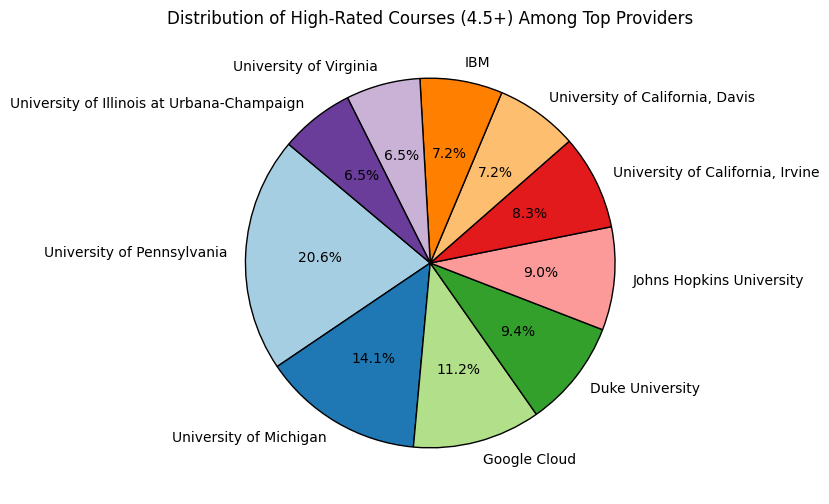

Top 10 Providers with the Most High-Rated Courses (4.5+):

University of Pennsylvania: 57 high-rated courses
University of Michigan: 39 high-rated courses
Google Cloud: 31 high-rated courses
Duke University: 26 high-rated courses
Johns Hopkins University: 25 high-rated courses
University of California, Irvine: 23 high-rated courses
University of California, Davis: 20 high-rated courses
IBM: 20 high-rated courses
University of Virginia: 18 high-rated courses
University of Illinois at Urbana-Champaign: 18 high-rated courses


In [24]:
high_rated_courses = df_cleaned[df_cleaned['course_rating'] >= 4.5]


top_providers = high_rated_courses.groupby('course_organization').size().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = plt.cm.Paired(range(len(top_providers)))  
top_providers.plot(kind='pie', autopct='%1.1f%%', colors=colors, startangle=140, wedgeprops={'edgecolor': 'black'})

plt.title("Distribution of High-Rated Courses (4.5+) Among Top Providers")
plt.ylabel("")  
plt.show()

print("Top 10 Providers with the Most High-Rated Courses (4.5+):\n")
for provider, count in top_providers.items():
    print(f"{provider}: {count} high-rated courses")

**What This Means:**
- The University of Pennsylvania stands out as the top provider, offering the most high-rated (4.5+) courses with a total of 57 courses. 
Other universities like Michigan (39 courses), Duke (26 courses), and Johns Hopkins (25 courses) also contribute significantly. 
Notably, Google Cloud and IBM appear in the list, indicating that tech-related platforms also offer highly-rated courses.
This distribution highlights that prestigious universities dominate the number of well-rated courses, but tech companies** are also strong competitors in online education.







### Which course providers offer the most course titles?

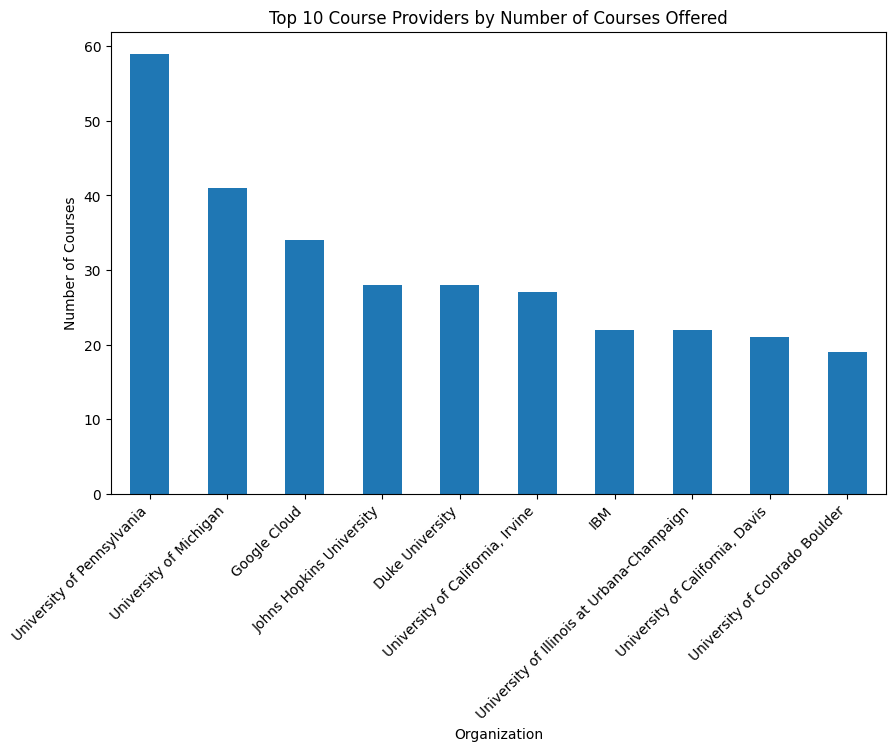

Top 10 Course Providers by Number of Courses Offered:

University of Pennsylvania: 59 courses
University of Michigan: 39 courses
Google Cloud: 33 courses
Johns Hopkins University: 28 courses
Duke University: 28 courses
University of California, Irvine: 27 courses
IBM: 22 courses
University of Illinois at Urbana-Champaign: 22 courses
University of California, Davis: 21 courses
University of Colorado Boulder: 19 courses


In [25]:
plt.figure(figsize=(10,6))
most_courses_providers = df['course_organization'].value_counts().head(10)
most_courses_providers.plot(kind='bar')
plt.title("Top 10 Course Providers by Number of Courses Offered")
plt.xlabel("Organization")
plt.ylabel("Number of Courses")
plt.xticks(rotation=45, ha='right')
plt.show()

most_courses_providers = df_cleaned['course_organization'].value_counts().head(10)

print("Top 10 Course Providers by Number of Courses Offered:\n")
for provider, count in most_courses_providers.items():
    print(f"{provider}: {count} courses")


**What This Means:** 
- The table lists the top 10 organizations offering the most courses on the platform. 
- The University of Pennsylvania leads with 59 courses, followed by the University of Michigan (39 courses) and Google Cloud (33 courses).
- Many top-ranking institutions, such as Duke University, Johns Hopkins University, and multiple University of California campuses, are among the leading providers.
- IBM is also a major contributor, reflecting its strong presence in tech-related courses.
- This suggests that elite universities and major tech companies dominate course offerings, providing diverse educational opportunities.

### What are the course certificates available? 

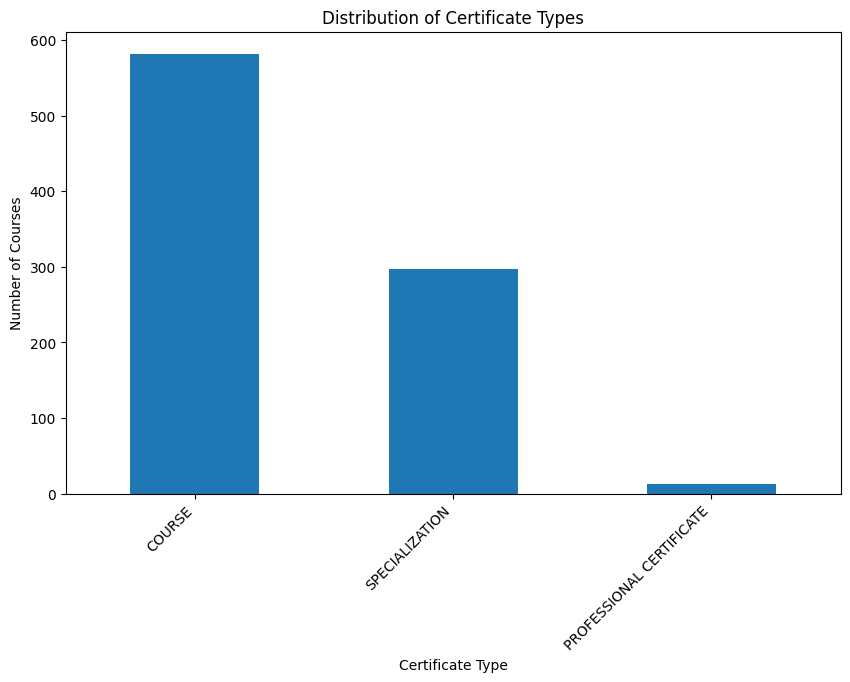

Number of Courses by Certificate Type:

COURSE: 582 courses
SPECIALIZATION: 297 courses
PROFESSIONAL CERTIFICATE: 12 courses


In [26]:
plt.figure(figsize=(10,6))
certificate_counts = df['course_Certificate_type'].str.strip().value_counts()
certificate_counts.plot(kind='bar')
plt.title("Distribution of Certificate Types")
plt.xlabel("Certificate Type")
plt.ylabel("Number of Courses")
plt.xticks(rotation=45, ha='right')
plt.show()

print("Number of Courses by Certificate Type:\n")
for cert_type, count in certificate_counts.items():
    print(f"{cert_type}: {count} courses")

**What This Means:**
- COURSE (582 courses): The most common category, representing standalone courses.
- SPECIALIZATION (297 courses): A structured series of courses designed to develop expertise in a specific subject.
- PROFESSIONAL CERTIFICATE (12 courses): The least common type, often targeted at industry-specific skills.
- This distribution indicates that the majority of offerings are standalone courses, with fewer structured learning paths and specialised professional certifications.

### How does enrollment vary across different course certificate types?

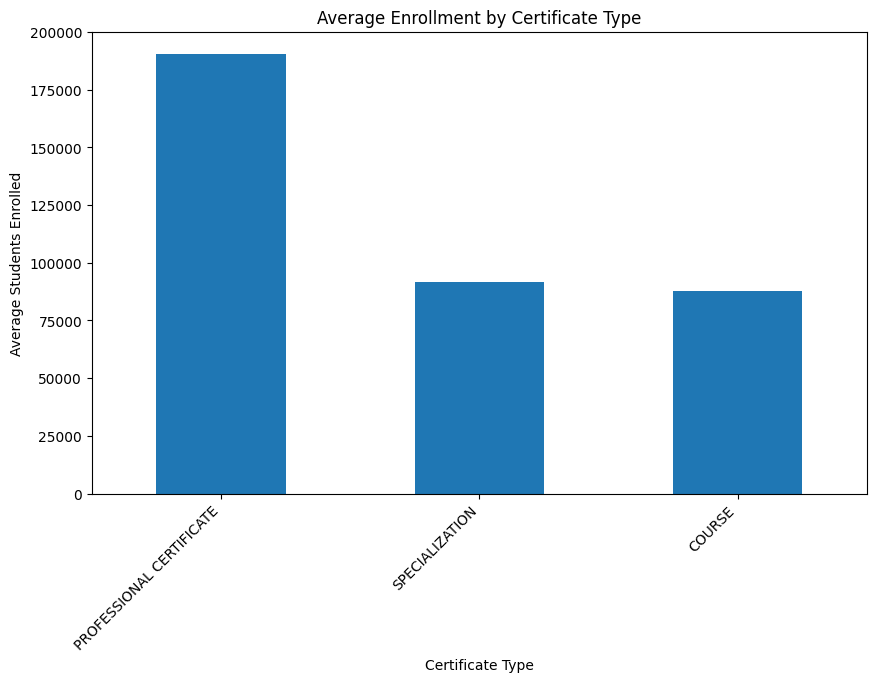

Average Enrollment by Certificate Type:

PROFESSIONAL CERTIFICATE: 190,700 students on average
SPECIALIZATION: 91,792 students on average
COURSE: 87,854 students on average


In [27]:
plt.figure(figsize=(10,6))
enrollment_by_certificate = df.groupby('course_Certificate_type')['course_students_enrolled'].mean().sort_values(ascending=False)
enrollment_by_certificate.plot(kind='bar')
plt.title("Average Enrollment by Certificate Type")
plt.xlabel("Certificate Type")
plt.ylabel("Average Students Enrolled")
plt.xticks(rotation=45, ha='right')
plt.show()

enrollment_by_certificate = df.groupby('course_Certificate_type')['course_students_enrolled'].mean().sort_values(ascending=False)

print("Average Enrollment by Certificate Type:\n")
for cert_type, avg_enrollment in enrollment_by_certificate.items():
    print(f"{cert_type}: {avg_enrollment:,.0f} students on average")

**What This Means:**
- The results indicate that Professional Certificates have the highest average enrollment, with approximately 190,700 students per course. This suggests that professional certification programs attract a large number of learners, likely due to their career-oriented nature.
- Specializations have an average enrollment of 91,792 students, showing that structured multi-course programs also appeal to a significant number of learners.
- Individual Courses have the lowest average enrollment at 87,854 students, which could indicate that while many learners take standalone courses, they are less likely to attract the same volume of students as career-focused or structured learning paths.

### Is there a correlation between course certificate types and course ratings?

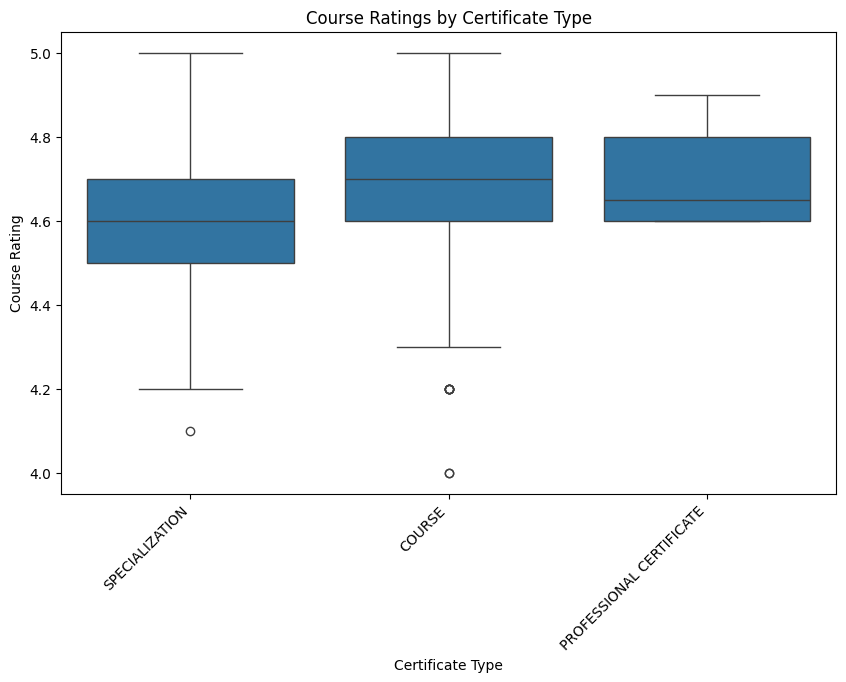


Course Ratings by Certificate Type:

COURSE:
  - Average Rating: 4.71
  - Minimum Rating: 4.00
  - Maximum Rating: 5.00

PROFESSIONAL CERTIFICATE:
  - Average Rating: 4.70
  - Minimum Rating: 4.60
  - Maximum Rating: 4.90

SPECIALIZATION:
  - Average Rating: 4.63
  - Minimum Rating: 4.10
  - Maximum Rating: 5.00



In [28]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_cleaned, x='course_Certificate_type', y='course_rating')
plt.title("Course Ratings by Certificate Type")
plt.xlabel("Certificate Type")
plt.ylabel("Course Rating")
plt.xticks(rotation=45, ha='right')
plt.show()

certificate_rating_stats = df_cleaned.groupby('course_Certificate_type')['course_rating'].describe()[['mean', 'min', 'max']]

print("\nCourse Ratings by Certificate Type:\n")
for cert_type, stats in certificate_rating_stats.iterrows():
    print(f"{cert_type.upper()}:")
    print(f"  - Average Rating: {stats['mean']:.2f}")
    print(f"  - Minimum Rating: {stats['min']:.2f}")
    print(f"  - Maximum Rating: {stats['max']:.2f}\n")

**What This Means:**
- Courses have the highest average rating of 4.71, with some courses rated as low as 4.00 and others achieving a perfect 5.00.
- Professional Certificates have an average rating of 4.70, with ratings ranging from 4.60 to 4.90. This suggests a consistently high-quality standard but a narrower range.
- Specializations have an average rating of 4.63, with ratings spanning 4.10 to 5.00, indicating more variability in course quality.
- Overall, the ratings are quite high across all certificate types, suggesting that learners generally find these courses valuable and well-designed.

### Are there any course providers that dominate the dataset in terms of enrollment and ratings?

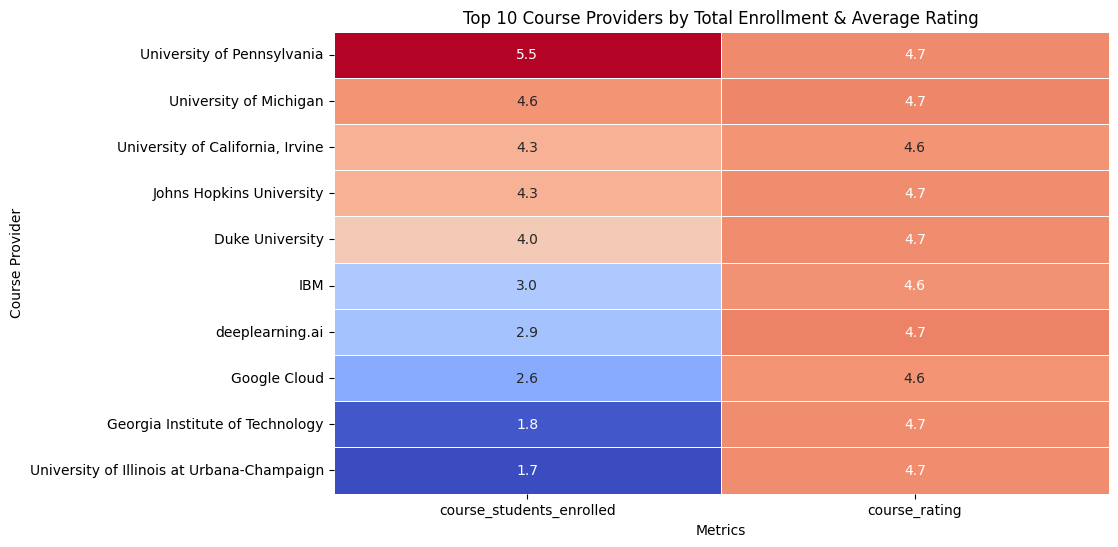


Top 10 Course Providers by Total Enrollment and Average Rating:

University of Pennsylvania: 5.5M students enrolled, Average Rating: 4.7
University of Michigan: 4.6M students enrolled, Average Rating: 4.7
University of California, Irvine: 4.3M students enrolled, Average Rating: 4.6
Johns Hopkins University: 4.3M students enrolled, Average Rating: 4.7
Duke University: 4.0M students enrolled, Average Rating: 4.7
IBM: 3.0M students enrolled, Average Rating: 4.6
deeplearning.ai: 2.9M students enrolled, Average Rating: 4.7
Google Cloud: 2.6M students enrolled, Average Rating: 4.6
Georgia Institute of Technology: 1.8M students enrolled, Average Rating: 4.7
University of Illinois at Urbana-Champaign: 1.7M students enrolled, Average Rating: 4.7


In [29]:

dominant_providers = df_cleaned.groupby('course_organization').agg({
    'course_students_enrolled': 'sum',
    'course_rating': 'mean'
})


dominant_providers = dominant_providers.sort_values(by=['course_students_enrolled', 'course_rating'], ascending=[False, False]).head(10)


dominant_providers['course_students_enrolled'] = dominant_providers['course_students_enrolled'] / 1_000_000
dominant_providers['course_students_enrolled'] = dominant_providers['course_students_enrolled'].apply(lambda x: f"{x:.1f}M")


dominant_providers['course_students_enrolled'] = dominant_providers['course_students_enrolled'].str.replace('M', '').astype(float)


plt.figure(figsize=(10, 6))
sns.heatmap(dominant_providers, annot=True, fmt=".1f", cmap="coolwarm", linewidths=0.5, cbar=False)
plt.title("Top 10 Course Providers by Total Enrollment & Average Rating")
plt.xlabel("Metrics")
plt.ylabel("Course Provider")
plt.show()  

print("\nTop 10 Course Providers by Total Enrollment and Average Rating:\n")
for provider, row in dominant_providers.iterrows():
    print(f"{provider}: {row['course_students_enrolled']}M students enrolled, Average Rating: {row['course_rating']:.1f}")




**What This Means:**
- Among the course providers dominating, we have University of Pennsylvania ranking the highest with a total enrollment of 5.5M students per course and an average rating of 4.7. University of Michigan follows with 4.6M students across all of their courses and an average rating of 4.7. 
- Top-rated universities dominate the rankings, showing a correlation between strong academic reputation and student interest.

# 4. Conclusions and Suggestions for Further Improvement

#### **Conclusions:**
- The dataset reveals that certain course providers, particularly universities like the University of Michigan and University of Pennsylvania, dominate in terms of both total enrollment and average course ratings.
- Course difficulty and student enrollment have an observable relationship, where beginner-level courses tend to attract more students.
- Specialization and Professional Certificates generally have higher enrollments compared to standalone courses, indicating that students prefer structured learning paths.
- Top-rated course providers are a mix of prestigious universities and tech companies, highlighting the demand for both academic and industry-focused learning.
- The most enrolled courses often align with high-demand subjects such as technology, business, and data science.

#### **Suggestions for Further Improvements:**
- **Enhancing Data Granularity:** Breaking down enrollment and ratings by subject area could provide deeper insights into the most popular fields.
- **Time-Based Trends:** Analysing how enrollments change over time would be useful to predict future demand for courses.
- **Sentiment Analysis on Reviews:** Extracting and analysing student reviews could add qualitative insights to complement the numerical ratings.
- **Course Completion Rates:** If available, integrating completion rates would provide a clearer picture of course effectiveness.
- **Pricing Impact:** Examining the relationship between course pricing (if applicable) and enrollments could help understand the role of affordability in course popularity.
